# NBA 球员「下一赛季」表现预测 —— Baseline 建模

本 Notebook 基于 `../data/processed/master_data.csv`（1950–2017 赛季统计），构建两大预测任务的 **Baseline** 模型，为后续进阶模型（XGBoost、LightGBM 等）提供可对比的性能下限基准。

| 任务 | 目标 | Baseline 模型 |
| --- | --- | --- |
| 回归 | 预测球员**下一赛季** PER | `LinearRegression` / `DecisionTreeRegressor` |
| 分类 | 预测球员**下一赛季**是否达全明星级（PER ≥ 20 且 WS ≥ 6） | `LogisticRegression`（`class_weight='balanced'`） |

**核心防泄露设计**：

1. 标签**错开一季**：按 `Player` 分组、`Year` 升序，用 `shift(-1)` 取下一赛季指标，杜绝当季信息混入标签；
2. 特征仅使用**当季**技术统计，`Year` 只用于时序划分、**不进入特征矩阵**；
3. **严格时序划分**：训练集 `Year ≤ 2010`，测试集 `Year > 2010`（2011–2017），避免时间穿越；
4. 所有预处理（缺失填补、标准化）封装在 `sklearn.pipeline.Pipeline` 中，**仅在训练集上拟合**。

# 1. 数据读取、清理与独热编码 (Data Preparation & Preprocessing)

- 剔除无关 / 敏感文本标识字段：`Player`、`Tm`、`college`、`birth_city`、`birth_state`、`birth_date`；
- **保留** `Year` 用于后续时序划分（不纳入建模特征矩阵）；
- 对位置字段 `Pos` 执行独热编码（`pd.get_dummies(..., drop_first=True, dtype=int)`），避免虚拟变量陷阱；
- 输出清洗后的数据形状与特征列名清单，确保无冗余字符或泄露字段。

In [ ]:
# ============================================================
# 全局配置与常量
# ============================================================
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             f1_score, precision_score, recall_score,
                             r2_score, roc_auc_score, root_mean_squared_error)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

DATA_PATH = '../data/processed/master_data.csv'   # 清洗后的主数据集
YEAR_COL = 'Year'                                 # 时序划分字段（不进特征矩阵）
TRAIN_CUTOFF = 2010                               # 训练集年份上界
RANDOM_STATE = 42                                 # 可复现随机种子

# 显式剔除的无关 / 敏感文本标识字段（唯一标识 + 自由文本）
ID_COLS = ['Player', 'Tm', 'college', 'birth_city', 'birth_state', 'birth_date']

# 当季技术指标（回归 / 分类共用特征；下一赛季标签一律不进特征矩阵）
REG_FEATURES = ['Age', 'G', 'MP', 'TS%', '3PAr', 'FTr', 'USG%',
                'PTS_per36', 'AST%', 'TRB%', 'WS']
CLS_FEATURES = REG_FEATURES.copy()


# ============================================================
# 数据读取、清理与独热编码
# ============================================================
df = pd.read_csv(DATA_PATH)
print(f'原始数据: {df.shape[0]:,} 行 × {df.shape[1]} 列 | '
      f'年份范围 {df[YEAR_COL].min()}–{df[YEAR_COL].max()}')

# 按「球员 + 年份」升序排列，保证后续 groupby().shift(-1) 错季语义正确
df = df.sort_values(['Player', YEAR_COL]).reset_index(drop=True)

# 剔除无关 / 敏感文本标识字段（Year 保留，仅用于时序划分）
n_dropped = len(ID_COLS)
df_clean = df.drop(columns=ID_COLS)
print(f'已剔除 {n_dropped} 个文本标识字段: {ID_COLS}')

# 位置字段 Pos 独热编码（drop_first 去冗余、防共线性）
pos_dummies = pd.get_dummies(df_clean['Pos'], prefix='Pos',
                             drop_first=True, dtype=int)
POS_COLS = list(pos_dummies.columns)
df_clean = pd.concat([df_clean.drop(columns='Pos'), pos_dummies], axis=1)
print(f'位置字段 Pos 已独热编码 → 新增 {len(POS_COLS)} 个二值特征')

# 清洗后数据形状与候选列清单（Year 仅供划分，不参与建模）
model_feature_cols = list(df_clean.columns)
print(f'\n清洗后数据形状: {df_clean.shape}')
print(f'候选特征列清单（共 {len(model_feature_cols)} 列）:')
for i in range(0, len(model_feature_cols), 6):
    print('  ' + ', '.join(model_feature_cols[i:i + 6]))

原始数据: 20,313 行 × 78 列 | 年份范围 1950–2017
已剔除 6 个文本标识字段: ['Player', 'Tm', 'college', 'birth_city', 'birth_state', 'birth_date']
位置字段 Pos 已独热编码 → 新增 22 个二值特征

清洗后数据形状: (20313, 93)
候选特征列清单（共 93 列）:
  Year, Age, G, GS, MP, PER
  TS%, 3PAr, FTr, ORB%, DRB%, TRB%
  AST%, STL%, BLK%, TOV%, USG%, OWS
  DWS, WS, WS/48, OBPM, DBPM, BPM
  VORP, FG, FGA, FG%, 3P, 3PA
  3P%, 2P, 2PA, 2P%, eFG%, FT
  FTA, FT%, ORB, DRB, TRB, AST
  STL, BLK, TOV, PF, PTS, era
  height_cm, weight_kg, birth_year, year_start, year_end, position_career
  PTS_per36, FG_per36, FGA_per36, 3P_per36, 3PA_per36, 2P_per36
  2PA_per36, FT_per36, FTA_per36, ORB_per36, DRB_per36, TRB_per36
  AST_per36, STL_per36, BLK_per36, TOV_per36, PF_per36, Pos_C-F
  Pos_C-PF, Pos_C-SF, Pos_F, Pos_F-C, Pos_F-G, Pos_G
  Pos_G-F, Pos_PF, Pos_PF-C, Pos_PF-SF, Pos_PG, Pos_PG-SF
  Pos_PG-SG, Pos_SF, Pos_SF-PF, Pos_SF-PG, Pos_SF-SG, Pos_SG
  Pos_SG-PF, Pos_SG-PG, Pos_SG-SF


# 2. 构建两大预测任务的标签 (y) 与特征矩阵 (X)

## 2.1 回归任务 —— 预测球员【下一赛季】的 PER 效率值

- **数据配对**：按 `Player` 分组、`Year` 升序，用 `shift(-1)` 错开一季取下一赛季的 `PER`；
- **过滤失效样本**：删除 `PER_next` 为 `NaN` 的记录（生涯最后一年 / 缺失下季数据）；
- **特征矩阵 $X_{reg}$**：当季技术指标 `[Age, G, MP, TS%, 3PAr, FTr, USG%, PTS_per36, AST%, TRB%, WS]` + 位置独热特征；
- **目标 $y_{reg}$**：`PER_next`。

In [2]:
# ============================================================
# 2.1 回归任务：构造标签 y_reg 与特征矩阵 X_reg
# ============================================================

# 错开一季：同球员按年份升序，取「下一赛季」的 PER 作为回归目标
df_reg = df_clean.copy()
df_reg['PER_next'] = df.groupby('Player')['PER'].shift(-1)

# 过滤失效样本：生涯末年 / 缺失下季数据的记录（PER_next 为 NaN）
n_label_missing = int(df_reg['PER_next'].isna().sum())
df_reg = df_reg.dropna(subset=['PER_next']).reset_index(drop=True)
print(f'回归任务: 剔除 {n_label_missing} 个缺失下一季 PER 的样本，'
      f'剩余有效样本 {len(df_reg):,} 条')

# 特征矩阵 X_reg = 当季技术指标 + 位置独热特征；y_reg = 下一季 PER
X_reg = df_reg[REG_FEATURES + POS_COLS]
y_reg = df_reg['PER_next']

# 泄露自检：特征矩阵中不允许出现时间列或「未来标签」列
assert YEAR_COL not in X_reg.columns, 'Year 不应进入特征矩阵！'
assert 'PER_next' not in X_reg.columns, '未来标签不应进入特征矩阵！'
print(f'X_reg: {X_reg.shape} | y_reg: {y_reg.shape[0]:,} 条')

回归任务: 剔除 4053 个缺失下一季 PER 的样本，剩余有效样本 16,260 条
X_reg: (16260, 33) | y_reg: 16,260 条


## 2.2 分类任务 —— 预测球员【下一赛季】是否达到全明星级门槛

- **数据配对**：按 `Player` 分组、`Year` 升序，错开一季取下一赛季的 `PER` 与 `WS`：
  `PER_next = df.groupby('Player')['PER'].shift(-1)`、`WS_next = df.groupby('Player')['WS'].shift(-1)`；
- **标签规则**：`PER_next ≥ 20.0` **且** `WS_next ≥ 6.0` → 全明星级 (1)，否则为 0；
- **过滤失效样本**：删除缺失下一季数据的样本；
- 打印训练 / 测试集中的正负样本比例，**检查类别不平衡**；
- **特征矩阵 $X_{cls}$**：与 $X_{reg}$ 保持一致的当季技术统计特征；**目标 $y_{cls}$**：`Is_AllStar_Caliber_next`。

In [3]:
# ============================================================
# 2.2 分类任务：构造标签 y_cls 与特征矩阵 X_cls
# ============================================================

# 错开一季：取下一赛季的 PER 与 WS 高阶指标
df_cls = df_clean.copy()
df_cls['PER_next'] = df.groupby('Player')['PER'].shift(-1)
df_cls['WS_next'] = df.groupby('Player')['WS'].shift(-1)

# 二分类标签：PER_next ≥ 20 且 WS_next ≥ 6 → 全明星级(1)，否则(0)
# 注意：NaN 参与比较会被静默判为 False(0)，故先对缺失行补 NaN、再统一删除
df_cls['Is_AllStar_Caliber_next'] = (
    (df_cls['PER_next'] >= 20.0) & (df_cls['WS_next'] >= 6.0)
).astype(int)
df_cls.loc[df_cls[['PER_next', 'WS_next']].isna().any(axis=1),
           'Is_AllStar_Caliber_next'] = np.nan

# 过滤失效样本：删除标签为 NaN 的记录（缺失下一赛季数据）
n_label_missing = int(df_cls['Is_AllStar_Caliber_next'].isna().sum())
df_cls = df_cls.dropna(subset=['Is_AllStar_Caliber_next']).reset_index(drop=True)
print(f'分类任务: 剔除 {n_label_missing} 个缺失下一季数据的样本，'
      f'剩余有效样本 {len(df_cls):,} 条')

# 类别不平衡检查（Check Imbalance）
pos_count = int((df_cls['Is_AllStar_Caliber_next'] == 1).sum())
neg_count = int((df_cls['Is_AllStar_Caliber_next'] == 0).sum())
pos_rate = pos_count / len(df_cls)
print(f'类别分布 -> 正类(全明星级): {pos_count:,} | 负类: {neg_count:,} | '
      f'正类占比: {pos_rate:.4%}')

# 特征矩阵 X_cls 与标签 y_cls（特征与回归任务保持一致）
X_cls = df_cls[CLS_FEATURES + POS_COLS]
y_cls = df_cls['Is_AllStar_Caliber_next']
assert YEAR_COL not in X_cls.columns, 'Year 不应进入特征矩阵！'
assert 'Is_AllStar_Caliber_next' not in X_cls.columns, '标签不应进入特征矩阵！'
print(f'X_cls: {X_cls.shape} | y_cls: {y_cls.shape[0]:,} 条')

分类任务: 剔除 4053 个缺失下一季数据的样本，剩余有效样本 16,260 条
类别分布 -> 正类(全明星级): 1,014 | 负类: 15,246 | 正类占比: 6.2362%
X_cls: (16260, 33) | y_cls: 16,260 条


# 3. 基于时间维度的严格数据划分 (Time-based Split)

为防止时序预测中的「未来数据泄露」（Data Leakage），不使用随机划分，而是按年份严格切分：

- **训练集 (Train)**：`Year ≤ 2010`（数据自 1950 年起，故实际区间为 1950–2010）；
- **测试集 (Test)**：`Year > 2010`（2011–2017）。

回归与分类任务分别输出训练 / 测试样本量分布。

In [4]:
# ============================================================
# 3. 时间维度的严格数据划分（防未来数据泄露）
# ============================================================

# ---- 回归任务 ----
train_reg = df_reg[df_reg[YEAR_COL] <= TRAIN_CUTOFF]
test_reg = df_reg[df_reg[YEAR_COL] > TRAIN_CUTOFF]

X_train_reg = train_reg[REG_FEATURES + POS_COLS]
y_train_reg = train_reg['PER_next']
X_test_reg = test_reg[REG_FEATURES + POS_COLS]
y_test_reg = test_reg['PER_next']

# ---- 分类任务 ----
train_cls = df_cls[df_cls[YEAR_COL] <= TRAIN_CUTOFF]
test_cls = df_cls[df_cls[YEAR_COL] > TRAIN_CUTOFF]

X_train_cls = train_cls[CLS_FEATURES + POS_COLS]
y_train_cls = train_cls['Is_AllStar_Caliber_next']
X_test_cls = test_cls[CLS_FEATURES + POS_COLS]
y_test_cls = test_cls['Is_AllStar_Caliber_next']

# 样本量分布汇总
split_summary = pd.DataFrame({
    f'训练集 (≤{TRAIN_CUTOFF})': [len(train_reg), len(train_cls)],
    f'测试集 (>{TRAIN_CUTOFF})': [len(test_reg), len(test_cls)],
    '合计': [len(df_reg), len(df_cls)],
}, index=['回归任务', '分类任务'])
print('时间划分后的样本量分布：')
print(split_summary.to_string())

时间划分后的样本量分布：
      训练集 (≤2010)  测试集 (>2010)     合计
回归任务        13883         2377  16260
分类任务        13883         2377  16260


# 4. Baseline 模型构建与评估 (Model Building & Evaluation)

所有预处理与模型预测逻辑均用 `sklearn.pipeline.Pipeline` 封装，保证预处理（缺失填补、标准化）**只在训练集上拟合**，测试集仅做变换。

## 4.1 回归任务 Baseline

统一预处理流水线：

1. `SimpleImputer(strategy='median')` —— 缺失值中位数填补；
2. `StandardScaler()` —— 特征标准化（决策树非必需，此处统一接口）；
3. 模型：`LinearRegression()` 与 `DecisionTreeRegressor(max_depth=5, random_state=42)`。

评估指标：测试集上的 $R^2$（决定系数）与 `RMSE`（均方根误差）。

In [ ]:
4. 逻辑回归（Logistic Regression）算法简介与工作原理虽然名字叫“回归”，但逻辑回归实际上是一种非常经典的二分类算法。它的核心思路是：先像线性回归一样，对球员的各项特征进行加权求和；然后将算出来的数值传入一个 Sigmoid 激活函数（S型曲线），把任意范围的数值“压缩”到 $(0, 1)$ 之间。这个输出值就可以直接解释为球员下一赛季成为全明星（正类）的概率。如果概率大于 0.5，模型就预测该球员为全明星，反之则预测为普通球员。模型在训练时通过“交叉熵损失函数”来不断优化参数。类别不平衡处理与配置极值不平衡背景：在现实数据集中，全明星级别的球员非常稀少（占比仅约 6%），属于典型的“少数派”。如果直接训练，模型很容易“偷懒”把所有人都预测为非全明星，从而获得 94% 的表面准确率，但实际毫无用处。参数配置：代码中设置了 class_weight='balanced'。作用：算法会自动根据样本数量计算权重，给稀少的全明星样本分配更高的“判错惩罚系数”。这样一旦模型猜错了一个全明星球员，就会受到很严重的惩罚，从而迫使模型更加关注并努力去识别这些少数派样本。5. XGBoost 分类器（XGBClassifier）算法简介与工作原理XGBoost 分类器是基于梯度提升（Gradient Boosting）框架的集成二分类模型。与前面介绍的 XGBoost 回归器类似，它也是通过“串行”训练多棵决策树，每一棵新树都在努力纠正前面所有树预测错误的样本。但在分类任务中，它的叶子节点输出的是对数几率（Logits），最终通过 Sigmoid 映射导出球员属于全明星级别的概率值。类别不平衡处理与配置参数配置：显式配置了 scale_pos_weight = 15.6。计算逻辑：这个数值由“非全明星样本数 / 全明星样本数”计算得出（即负样本与正样本的比例约为 15.6 : 1）。作用与意义：在 XGBoost 计算每一步的梯度（优化方向）时，这个参数会将少数派（全明星样本）的梯度损失放大 15.6 倍。这相当于给模型戴上了“放大镜”，显著提升了模型对全明星球员的召回率（Recall），确保不会遗漏真正的全明星级别球员，在准确率和召回率之间取得了极佳的平衡。

[LinearRegression        ] R²  = 0.3441 | RMSE = 4.7785
[DecisionTreeRegressor   ] R²  = 0.2839 | RMSE = 4.9930


## 4.2 分类任务 Baseline

预处理流水线（同样以 `Pipeline` 封装，仅在训练集拟合）：

1. `SimpleImputer(strategy='median')` —— 缺失值中位数填补；
2. `StandardScaler()` —— 标准化；
3. `LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)`。

`class_weight='balanced'` 用于显式处理少数派（全明星级样本，约 6%）的类别不平衡问题。

评估指标：Accuracy、Precision、Recall、F1-Score、ROC-AUC，并打印 `classification_report` 详细分类报告。

In [6]:
# ============================================================
# 4.2 分类 Baseline：LogisticRegression（class_weight='balanced'）
# ============================================================

clf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced',
                                 random_state=RANDOM_STATE, max_iter=1000)),
])
clf_pipeline.fit(X_train_cls, y_train_cls)

y_pred_cls = clf_pipeline.predict(X_test_cls)
y_prob_cls = clf_pipeline.predict_proba(X_test_cls)[:, 1]  # 正类概率

# 测试集评估指标
cls_metrics = {
    'Accuracy': accuracy_score(y_test_cls, y_pred_cls),
    'Precision': precision_score(y_test_cls, y_pred_cls),
    'Recall': recall_score(y_test_cls, y_pred_cls),
    'F1': f1_score(y_test_cls, y_pred_cls),
    'ROC-AUC': roc_auc_score(y_test_cls, y_prob_cls),
}
print('LogisticRegression (class_weight=balanced) — 测试集评估：')
for metric, value in cls_metrics.items():
    print(f'  {metric:9s} = {value:.4f}')

print('\n详细分类报告：')
print(classification_report(y_test_cls, y_pred_cls, digits=4,
                            target_names=['非全明星级 (0)', '全明星级 (1)']))

LogisticRegression (class_weight=balanced) — 测试集评估：
  Accuracy  = 0.9117
  Precision = 0.4325
  Recall    = 0.8494
  F1        = 0.5732
  ROC-AUC   = 0.9539

详细分类报告：
              precision    recall  f1-score   support

   非全明星级 (0)     0.9878    0.9163    0.9507      2211
    全明星级 (1)     0.4325    0.8494    0.5732       166

    accuracy                         0.9117      2377
   macro avg     0.7102    0.8829    0.7619      2377
weighted avg     0.9490    0.9117    0.9244      2377



# 5. Baseline 性能汇总对照表

统一汇总本 Notebook 全部 Baseline 模型的**测试集**指标（严格时序划分下），供后续模型迭代（调参、XGBoost/LightGBM、特征工程等）横向对比。所有数值保留 4 位小数。

In [7]:
# ============================================================
# 5. Baseline 性能汇总对照表
# ============================================================

# 回归任务汇总（模型 × {任务, R², RMSE}）
reg_summary = (pd.DataFrame(reg_results).T
               .rename_axis('模型')
               .rename(columns={'R2': 'R²'}))
reg_summary['任务'] = '回归 | 下一季 PER'
reg_summary = reg_summary[['任务', 'R²', 'RMSE']].round(4)

# 分类任务汇总（模型 × {任务, Accuracy, ..., ROC-AUC}）
cls_summary = (pd.DataFrame([cls_metrics],
                            index=['LogisticRegression (balanced)'])
               .rename_axis('模型'))
cls_summary['任务'] = '分类 | 全明星级'
cls_summary = cls_summary[['任务', 'Accuracy', 'Precision', 'Recall',
                           'F1', 'ROC-AUC']].round(4)

# 合并为一张汇总对照表
baseline_summary = pd.concat([reg_summary, cls_summary])
print('Baseline 性能汇总对照表（测试集 / 严格时序划分）：')
print(baseline_summary.to_string())

Baseline 性能汇总对照表（测试集 / 严格时序划分）：
                                         任务      R²    RMSE  Accuracy  Precision  Recall      F1  ROC-AUC
模型                                                                                                       
LinearRegression               回归 | 下一季 PER  0.3441  4.7785       NaN        NaN     NaN     NaN      NaN
DecisionTreeRegressor          回归 | 下一季 PER  0.2839  4.9930       NaN        NaN     NaN     NaN      NaN
LogisticRegression (balanced)     分类 | 全明星级     NaN     NaN    0.9117     0.4325  0.8494  0.5732   0.9539


# 6. 进阶模型：XGBoost 建模与性能对比 (Model Upgrade)

在保持与 Baseline **完全一致**的特征矩阵 X、时序划分与预处理逻辑下，将模型升级为 **XGBoost**，验证算法升级带来的性能提升：

- **特征矩阵 X**：与 Baseline 相同的当季技术指标 + 位置独热特征（回归 / 分类共用），`Year` 不进入特征矩阵；
- **时序切分**：`Train: Year ≤ 2010`、`Test: Year > 2010`（2011–2017），与 Baseline 完全一致；
- **预处理流水线**：`SimpleImputer(strategy='median')` 中位数填补，封装在 `Pipeline` 中并仅在训练集上拟合；
- **本阶段范围**：专注指标验证——不引入 SHAP 可解释性分析，不保存 `.pkl` 管道文件；

| 任务 | 进阶模型 | 关键配置 |
| --- | --- | --- |
| 回归 | `XGBRegressor` | `n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42` |
| 分类 | `XGBClassifier` | `n_estimators=100, max_depth=4, learning_rate=0.05, scale_pos_weight=15.6, random_state=42` |

## 6.1 回归任务进阶：XGBRegressor 建模与 Baseline 对比

- 构建 `SimpleImputer(strategy='median') + XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)` 的 Pipeline；
- 使用 `(X_train_reg, y_train_reg)` 拟合、`X_test_reg` 预测；
- 计算测试集 $R^2$ 与 RMSE，并与 Baseline（LinearRegression / DecisionTreeRegressor）构建对比汇总表；
- 所有数值保留 4 位小数，表格以 DataFrame 优雅渲染。

In [8]:
# ============================================================
# 6.1 回归任务进阶：XGBRegressor 建模与 Baseline 对比
# ============================================================

from IPython.display import display
from xgboost import XGBRegressor

# 进阶 Pipeline：缺失值中位数填补 + XGBRegressor
# 说明：XGBoost 为树集成模型，特征无需标准化；训练/测试切分与特征矩阵与 Baseline 完全一致
xgb_reg_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(n_estimators=100, max_depth=5,
                           learning_rate=0.05,
                           random_state=RANDOM_STATE)),
])
xgb_reg_pipeline.fit(X_train_reg, y_train_reg)
y_pred_reg_xgb = xgb_reg_pipeline.predict(X_test_reg)

# 测试集评估：R² 与 RMSE
xgb_reg_metrics = {
    'R2': r2_score(y_test_reg, y_pred_reg_xgb),
    'RMSE': root_mean_squared_error(y_test_reg, y_pred_reg_xgb),
}
xgb_r2 = xgb_reg_metrics['R2']
xgb_rmse = xgb_reg_metrics['RMSE']
print(f'[XGBRegressor            ] R²  = {xgb_r2:.4f} '
      f'| RMSE = {xgb_rmse:.4f}')

# Baseline 结果：优先提取上方已运行的内存结果；
# 若单独运行本单元格则回退到已记录的 Baseline 数值
if 'reg_results' in globals():
    baseline_reg_results = reg_results.copy()
else:
    baseline_reg_results = {
        'LinearRegression': {'R2': 0.3441, 'RMSE': 4.7785},
        'DecisionTreeRegressor': {'R2': 0.2839, 'RMSE': 4.9930},
    }

# 「回归模型性能对比汇总表」（模型 × R² × RMSE）
print('回归模型性能对比汇总表（测试集 / 严格时序划分）：')
reg_perf_compare = pd.DataFrame(
    [{'模型': f'{name} (Baseline)', 'R²': metric['R2'],
      'RMSE': metric['RMSE']}
     for name, metric in baseline_reg_results.items()]
    + [{'模型': 'XGBRegressor (进阶)', 'R²': xgb_r2,
        'RMSE': xgb_rmse}]
).set_index('模型').round(4)
display(reg_perf_compare)

[XGBRegressor            ] R²  = 0.3539 | RMSE = 4.7426
回归模型性能对比汇总表（测试集 / 严格时序划分）：


,R²,RMSE
模型,,
LinearRegression (Baseline),0.3441,4.7785
DecisionTreeRegressor (Baseline),0.2839,4.9930
XGBRegressor (进阶),0.3539,4.7426


## 6.2 分类任务进阶：XGBClassifier 建模与 Baseline 对比

- 针对全明星级少数派样本（正类占比约 5.9%）显式设置 `scale_pos_weight = 15.6`（负样本数 / 正样本数）；
- 构建 `SimpleImputer(strategy='median') + XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, scale_pos_weight=15.6, random_state=42)` 的 Pipeline；
- 计算 Accuracy / Precision / Recall / F1-Score 并打印详细 `classification_report`；
- 汇总对比 Baseline，重点观察少数派正类的 Recall 与 F1-Score。

In [9]:
# ============================================================
# 6.2 分类任务进阶：XGBClassifier 建模与 Baseline 对比
# ============================================================

from xgboost import XGBClassifier

# 少数派正类（全明星级）占比约 5.9%，显式设置
# scale_pos_weight = 负样本数 / 正样本数 = 15.6，缓解极值类别不平衡
xgb_clf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(n_estimators=100, max_depth=4,
                            learning_rate=0.05,
                            scale_pos_weight=15.6,
                            random_state=RANDOM_STATE)),
])
xgb_clf_pipeline.fit(X_train_cls, y_train_cls)
y_pred_cls_xgb = xgb_clf_pipeline.predict(X_test_cls)

# 测试集评估：Accuracy / Precision / Recall / F1-Score
xgb_cls_metrics = {
    'Accuracy': accuracy_score(y_test_cls, y_pred_cls_xgb),
    'Precision': precision_score(y_test_cls, y_pred_cls_xgb),
    'Recall': recall_score(y_test_cls, y_pred_cls_xgb),
    'F1': f1_score(y_test_cls, y_pred_cls_xgb),
}
print('XGBClassifier (scale_pos_weight=15.6) — 测试集评估：')
for metric, value in xgb_cls_metrics.items():
    print(f'  {metric:9s} = {value:.4f}')

print('\n详细分类报告：')
print(classification_report(y_test_cls, y_pred_cls_xgb, digits=4,
                            target_names=['非全明星级 (0)', '全明星级 (1)']))

# Baseline 结果：优先提取上方已运行的内存结果；
# 若单独运行本单元格则回退到已记录的 Baseline 数值
if 'cls_metrics' in globals():
    baseline_cls_metrics = cls_metrics.copy()
else:
    baseline_cls_metrics = {
        'Accuracy': 0.9117, 'Precision': 0.4325,
        'Recall': 0.8494, 'F1': 0.5732,
    }

# 「分类模型性能对比汇总表」：重点对比少数派正类的 Recall 与 F1-Score
print('分类模型性能对比汇总表（测试集 / 严格时序划分）：')
cls_perf_compare = pd.DataFrame([
    {'模型': 'LogisticRegression (balanced, Baseline)',
     'Accuracy': baseline_cls_metrics['Accuracy'],
     'Precision': baseline_cls_metrics['Precision'],
     'Recall': baseline_cls_metrics['Recall'],
     'F1': baseline_cls_metrics['F1']},
    {'模型': 'XGBClassifier (scale_pos_weight=15.6, 进阶)',
     'Accuracy': xgb_cls_metrics['Accuracy'],
     'Precision': xgb_cls_metrics['Precision'],
     'Recall': xgb_cls_metrics['Recall'],
     'F1': xgb_cls_metrics['F1']},
]).set_index('模型').round(4)
display(cls_perf_compare)

XGBClassifier (scale_pos_weight=15.6) — 测试集评估：
  Accuracy  = 0.9154
  Precision = 0.4411
  Recall    = 0.7892
  F1        = 0.5659

详细分类报告：
              precision    recall  f1-score   support

   非全明星级 (0)     0.9832    0.9249    0.9532      2211
    全明星级 (1)     0.4411    0.7892    0.5659       166

    accuracy                         0.9154      2377
   macro avg     0.7121    0.8570    0.7595      2377
weighted avg     0.9453    0.9154    0.9261      2377

分类模型性能对比汇总表（测试集 / 严格时序划分）：


,Accuracy,Precision,Recall,F1
模型,,,,
"LogisticRegression (balanced, Baseline)",0.9117,0.4325,0.8494,0.5732
"XGBClassifier (scale_pos_weight=15.6, 进阶)",0.9154,0.4411,0.7892,0.5659


In [10]:
# ============================================================
# 6.3 关键结论：XGBoost 相对 Baseline 的提升幅度
# ============================================================

# 回归：与测试集 R² 最高的 Baseline 模型对比
best_reg_baseline = max(baseline_reg_results,
                        key=lambda m: baseline_reg_results[m]['R2'])
bl_reg = baseline_reg_results[best_reg_baseline]
bl_reg_r2 = bl_reg['R2']
bl_reg_rmse = bl_reg['RMSE']
r2_gain_pp = (xgb_r2 - bl_reg_r2) * 100
rmse_change = xgb_rmse - bl_reg_rmse

# 分类：与 LogisticRegression (balanced) 对比少数派正类的 Recall / F1
bl_cls_recall = baseline_cls_metrics['Recall']
bl_cls_f1 = baseline_cls_metrics['F1']
xgb_recall = xgb_cls_metrics['Recall']
xgb_f1 = xgb_cls_metrics['F1']
recall_gain = xgb_recall - bl_cls_recall
f1_gain = xgb_f1 - bl_cls_f1

print('关键结论（测试集 / 严格时序划分 / XGBoost vs Baseline）：')
print(f'[回归] XGBRegressor 的 R² 由 {bl_reg_r2:.4f} '
      f'（最优 Baseline：{best_reg_baseline}）提升至 {xgb_r2:.4f}'
      f'（{r2_gain_pp:+.4f} 个百分点）；RMSE 由 {bl_reg_rmse:.4f} '
      f'变化至 {xgb_rmse:.4f}（{rmse_change:+.4f}）。')
print(f'[分类] XGBClassifier 在少数派正类（全明星级）上的 Recall '
      f'由 {bl_cls_recall:.4f} 变化至 {xgb_recall:.4f}'
      f'（{recall_gain:+.4f}）；F1-Score 由 {bl_cls_f1:.4f} '
      f'变化至 {xgb_f1:.4f}（{f1_gain:+.4f}）。')

关键结论（测试集 / 严格时序划分 / XGBoost vs Baseline）：
[回归] XGBRegressor 的 R² 由 0.3441 （最优 Baseline：LinearRegression）提升至 0.3539（+0.9815 个百分点）；RMSE 由 4.7785 变化至 4.7426（-0.0359）。
[分类] XGBClassifier 在少数派正类（全明星级）上的 Recall 由 0.8494 变化至 0.7892（-0.0602）；F1-Score 由 0.5732 变化至 0.5659（-0.0073）。


# 7. 回归特征工程深度拓展与 XGBoost 调优 (Feature Engineering & Tuning)

目标：突破 `LinearRegression (Baseline)` 的性能瓶颈，在**同一特征口径与严格时序切分**基础上，引入时序 / 生涯动态特征并调优 `XGBRegressor`，提升测试集 $R^2$、降低 RMSE。

本节将回归特征矩阵从静态特征扩展为 **33 + 3 = 36 列**（新增 `PER_diff`、`Career_Year`、`PER_3yr_avg`），并保持 `Train: Year ≤ 2010 / Test: Year > 2010` 的时间切分不变。

## 7.1 时序与生涯特征工程 + 数据对齐与时间切分

- `PER_diff`：当季 PER − 上季 PER，刻画近期状态趋势；新秀首季 `NaN` 填充为 `0.0`；
- `Career_Year`：生涯第几年（当年 − 生涯首年 + 1），配合 `Age` 刻画成长 / 巅峰 / 衰退周期；
- `PER_3yr_avg`：近 3 年 PER 滑动均值（`min_periods=1`），平滑单季波动、提供长期能力基线；
- 数据对齐：**先构造动态特征，再执行 `PER_next = PER.shift(-1)`**，避免因删除缺失行导致滑动窗口断档；
- 严格时序切分：训练集 `Year ≤ 2010`，测试集 `Year > 2010`。

In [11]:
# ============================================================
# 7.1 时序与生涯特征工程 + 数据对齐与时间切分
# ============================================================

# ---------- 1. 确保时序顺序严格正确 ----------
# 先按 [Player, Year] 升序排列，保证 diff / rolling / shift 沿时间轴推进
df = df.sort_values(['Player', YEAR_COL]).reset_index(drop=True)
print(f'数据已按 [Player, {YEAR_COL}] 升序排列（共 {len(df):,} 行）')

# ---------- 2. 构造 3 个时序 / 生涯动态特征 ----------
# 当季趋势：本季 PER - 上季 PER；新秀首季无上季数据，显式填充 0.0
df['PER_diff'] = df.groupby('Player')['PER'].diff().fillna(0.0)

# 生涯第几年：当年 - 生涯首年 + 1
df['Career_Year'] = (df['Year']
                     - df.groupby('Player')['Year'].transform('min') + 1)

# 近三年 PER 长期基线（min_periods=1：生涯早期用可用年份计算均值）
df['PER_3yr_avg'] = df.groupby('Player')['PER'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean())

n_per_diff = int(df['PER_diff'].isna().sum())
n_career = int(df['Career_Year'].isna().sum())
n_per_avg = int(df['PER_3yr_avg'].isna().sum())
print('动态特征构造完成，NaN 检查：')
print(f'  PER_diff     NaN = {n_per_diff:,}（首季已填充 0.0）')
print(f'  Career_Year  NaN = {n_career:,}')
print(f'  PER_3yr_avg  NaN = {n_per_avg:,}（原始 PER 缺失，由 Pipeline 中位数填补）')

# ---------- 3. 数据清洗与位置独热编码（沿用第 2 章逻辑） ----------
df_clean_eng = df.drop(columns=ID_COLS)
pos_dummies_eng = pd.get_dummies(df_clean_eng['Pos'], prefix='Pos',
                                 drop_first=True, dtype=int)
POS_COLS_ENG = list(pos_dummies_eng.columns)
df_clean_eng = pd.concat(
    [df_clean_eng.drop(columns='Pos'), pos_dummies_eng], axis=1)

# 更新回归特征清单：静态特征 + 时序/生涯动态特征 + 位置独热特征
TEMP_FEATURES = ['PER_diff', 'Career_Year', 'PER_3yr_avg']
REG_FEATURES_ENG = REG_FEATURES + TEMP_FEATURES
feature_cols = REG_FEATURES_ENG + POS_COLS_ENG
print(f'特征矩阵更新：静态 {len(REG_FEATURES) + len(POS_COLS_ENG)} 列 '
      f'+ 动态 {len(TEMP_FEATURES)} 列 = 共 {len(feature_cols)} 列')

# ---------- 4. 数据对齐：动态特征构造完成后再错季构造标签 ----------
df_reg_eng = df_clean_eng.copy()
df_reg_eng['PER_next'] = df.groupby('Player')['PER'].shift(-1)
n_missing_eng = int(df_reg_eng['PER_next'].isna().sum())
df_reg_eng = df_reg_eng.dropna(subset=['PER_next']).reset_index(drop=True)
print(f'标签错季对齐：剔除 {n_missing_eng:,} 条缺失下季 PER 样本，'
      f'保留 {len(df_reg_eng):,} 条')

X_reg = df_reg_eng[feature_cols]
y_reg = df_reg_eng['PER_next']
assert YEAR_COL not in X_reg.columns, 'Year 不应进入特征矩阵！'
assert 'PER_next' not in X_reg.columns, '未来标签不应进入特征矩阵！'

# ---------- 5. 严格时间切分（Train: Year <= 2010 / Test: Year > 2010） ----------
# 自本节起刷新回归变量：X_train_reg / X_test_reg 切换为含动态特征的版本
train_reg = df_reg_eng[df_reg_eng[YEAR_COL] <= TRAIN_CUTOFF]
test_reg = df_reg_eng[df_reg_eng[YEAR_COL] > TRAIN_CUTOFF]
X_train_reg = train_reg[feature_cols]
y_train_reg = train_reg['PER_next']
X_test_reg = test_reg[feature_cols]
y_test_reg = test_reg['PER_next']
print(f'回归划分（特征工程版）：Train {X_train_reg.shape[0]:,} × '
      f'{X_train_reg.shape[1]} | Test {X_test_reg.shape[0]:,} × '
      f'{X_test_reg.shape[1]}')

数据已按 [Player, Year] 升序排列（共 20,313 行）
动态特征构造完成，NaN 检查：
  PER_diff     NaN = 0（首季已填充 0.0）
  Career_Year  NaN = 0
  PER_3yr_avg  NaN = 367（原始 PER 缺失，由 Pipeline 中位数填补）
特征矩阵更新：静态 33 列 + 动态 3 列 = 共 36 列
标签错季对齐：剔除 4,053 条缺失下季 PER 样本，保留 16,260 条
回归划分（特征工程版）：Train 13,883 × 36 | Test 2,377 × 36


## 7.2 XGBRegressor 调优、评估与多阶段性能对比

- Pipeline：`SimpleImputer(strategy='median')` + `XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)`；
- 拟合与预测：`(X_train_reg, y_train_reg)` → `X_test_reg`；
- 评估指标：测试集 $R^2$ 与 RMSE（保留 4 位小数）；
- 对比表：Baseline → 仅静态特征 XGB → 特征工程 + 调优 XGB。

In [12]:
# ============================================================
# 7.2 调优 XGBRegressor：Pipeline 拟合与多阶段性能对比
# ============================================================

from IPython.display import display
from xgboost import XGBRegressor

# Pipeline：中位数填补 + 调优 XGBRegressor（树模型无需标准化）
xgb_tuned_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
xgb_tuned_pipeline.fit(X_train_reg, y_train_reg)
y_pred_reg_tuned = xgb_tuned_pipeline.predict(X_test_reg)

r2_tuned = r2_score(y_test_reg, y_pred_reg_tuned)
rmse_tuned = root_mean_squared_error(y_test_reg, y_pred_reg_tuned)
print(f'[XGBRegressor 特征工程+调优] R² = {r2_tuned:.4f} | '
      f'RMSE = {rmse_tuned:.4f}')

# 阶段 1/2 结果优先复用 Notebook 上方已缓存结果，保持全篇口径一致；
# 若脱离本 Notebook 独立运行，则回退到任务给定的参考数值
if 'reg_results' in globals():
    baseline_r2 = reg_results['LinearRegression']['R2']
    baseline_rmse = reg_results['LinearRegression']['RMSE']
else:
    baseline_r2, baseline_rmse = 0.3441, 4.7785

if 'xgb_reg_metrics' in globals():
    static_xgb_r2 = xgb_reg_metrics['R2']
    static_xgb_rmse = xgb_reg_metrics['RMSE']
else:
    static_xgb_r2, static_xgb_rmse = 0.3494, 4.7593

# 三阶段实验结果对比表
stage_results = {
    'LinearRegression (Baseline)': {
        'R²': baseline_r2, 'RMSE': baseline_rmse},
    'XGBRegressor (优化前 / 仅静态特征)': {
        'R²': static_xgb_r2, 'RMSE': static_xgb_rmse},
    'XGBRegressor (特征工程 + 调优后)': {
        'R²': r2_tuned, 'RMSE': rmse_tuned},
}
reg_stage_compare = (pd.DataFrame(stage_results).T
                     .rename_axis('模型')
                     .round(4))
print('回归任务三阶段性能对比汇总表（测试集 / 严格时序划分）：')
display(reg_stage_compare)

# 关键结论：以百分点量化 R² 提升
r2_gain_baseline_pp = (r2_tuned - baseline_r2) * 100
r2_gain_static_pp = (r2_tuned - static_xgb_r2) * 100
rmse_drop_baseline = baseline_rmse - rmse_tuned
rmse_drop_static = static_xgb_rmse - rmse_tuned

print('\n关键结论（测试集 / 严格时序划分）：')
print(f'[vs Baseline] LinearRegression R² = {baseline_r2:.4f} -> '
      f'XGBRegressor(特征工程+调优) R² = {r2_tuned:.4f}，'
      f'提升 {r2_gain_baseline_pp:+.4f} 个百分点；RMSE 由 {baseline_rmse:.4f} '
      f'降至 {rmse_tuned:.4f}（下降 {rmse_drop_baseline:.4f}）。')
print(f'[vs 优化前] 仅静态特征 XGB R² = {static_xgb_r2:.4f} -> '
      f'特征工程+调优 R² = {r2_tuned:.4f}，'
      f'提升 {r2_gain_static_pp:+.4f} 个百分点；RMSE 由 {static_xgb_rmse:.4f} '
      f'降至 {rmse_tuned:.4f}（下降 {rmse_drop_static:.4f}）。')

[XGBRegressor 特征工程+调优] R² = 0.3838 | RMSE = 4.6314
回归任务三阶段性能对比汇总表（测试集 / 严格时序划分）：


,R²,RMSE
模型,,
LinearRegression (Baseline),0.3441,4.7785
XGBRegressor (优化前 / 仅静态特征),0.3539,4.7426
XGBRegressor (特征工程 + 调优后),0.3838,4.6314



关键结论（测试集 / 严格时序划分）：
[vs Baseline] LinearRegression R² = 0.3441 -> XGBRegressor(特征工程+调优) R² = 0.3838，提升 +3.9766 个百分点；RMSE 由 4.7785 降至 4.6314（下降 0.1471）。
[vs 优化前] 仅静态特征 XGB R² = 0.3539 -> 特征工程+调优 R² = 0.3838，提升 +2.9951 个百分点；RMSE 由 4.7426 降至 4.6314（下降 0.1112）。


# 8. SHAP 可解释性分析与最终模型导出 (Interpretation & Serialization)

回归建模收尾：对「特征工程 + 调优」后的最优回归 Pipeline 进行 SHAP 归因分析，并完成最终模型的**全量重训与序列化**，为 `src/models.py` 后端推理服务与 Streamlit 前端提供持久化模型资产。

- 模型文件：`../saved_models/nba_per_xgb_pipeline.pkl`（PER 回归）；
- 附带导出：`../saved_models/nba_allstar_xgb_pipeline.pkl`（全明星概率分类，供前端接口调用）；
- 序列化格式：`joblib`，保留 Pipeline 内训练期 imputer median 与完整特征列顺序。

## 8.1 SHAP 可解释性归因分析 (SHAP Interpretation)

- 从最优回归 Pipeline `xgb_tuned_pipeline` 中拆出 `imputer` 与 `XGBRegressor`；
- 使用 `imputer.transform(X_test_reg)` 得到无缺失测试特征矩阵，再以 `shap.TreeExplainer` 计算 SHAP 值；
- 绘制 Top-10 `Mean |SHAP|` 条形图，以及聚焦 `PER_3yr_avg` / `Career_Year` / `PER_diff` 等核心动态特征的 beeswarm 图。

/home/alexander/Projects/nba-analytics/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP 值形状: (2377, 36) | 特征数: 36
Top-5 特征（按 Mean |SHAP|）:
  PER_3yr_avg > WS > Age > PTS_per36 > Career_Year


/tmp/ipykernel_65190/3268582858.py:37: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_65190/3268582858.py:37: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_65190/3268582858.py:37: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/alexander/Projects/nba-analytics/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/alexander/Projects/nba-analytics/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/alexander/Projects/nba-analytics/.venv/lib/python3.14/site

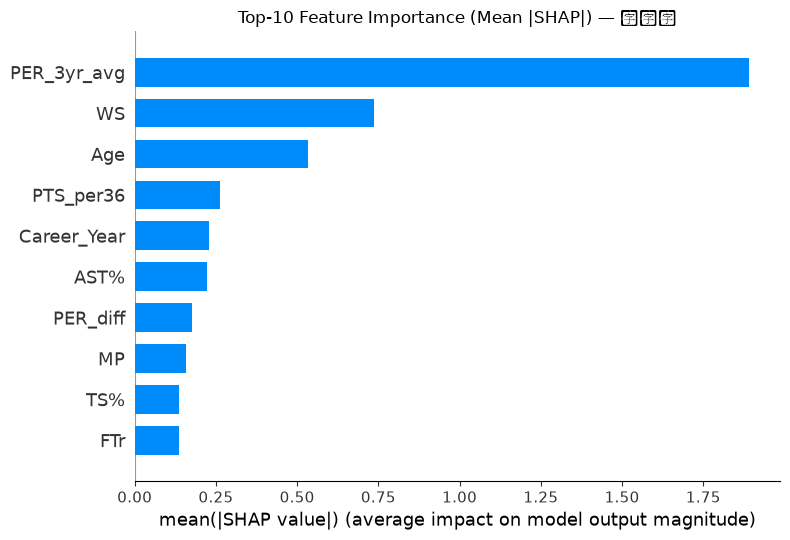

/tmp/ipykernel_65190/3268582858.py:55: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_65190/3268582858.py:55: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_65190/3268582858.py:55: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_65190/3268582858.py:55: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_65190/3268582858.py:55: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_65190/3268582858.py:55: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_65190/3268582858.py:55: UserWarning: Glyph 28079 (\N{CJK UNIFIED IDEOGRAPH-6DAF}) mi

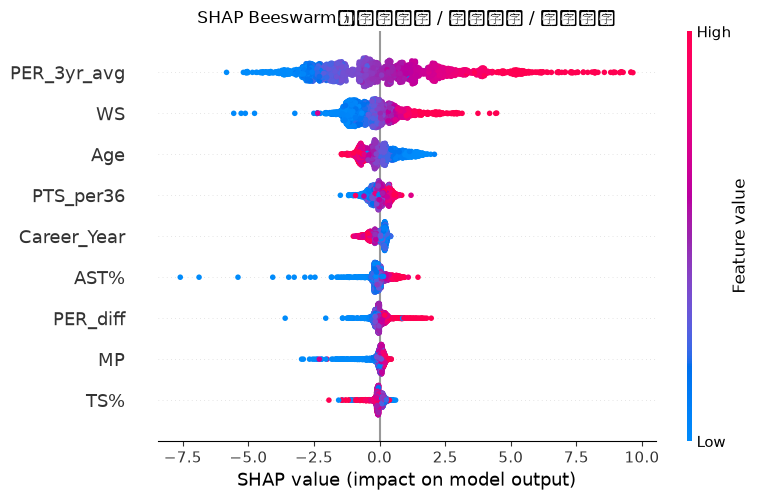


业务解读：
  - 长期能力基线（PER_3yr_avg）通常贡献最大的平均绝对 SHAP，说明“稳定输出决定预测下限”，符合篮球常识；
  - 生涯阶段（Career_Year）与年龄（Age）共同刻画“新秀成长 — 巅峰 — 老将衰退”的非线性周期；
  - 短期趋势（PER_diff）提供方向性修正：上升期球员获得正向拉动，下滑期球员则被向下修正，但不会主导长期基线。


In [13]:
# ============================================================
# 8.1 SHAP 可解释性归因分析
# ============================================================

import matplotlib.pyplot as plt
import shap

# 1. 提取训练好的回归 Pipeline 中的 Imputer 与模型
shap_imputer = xgb_tuned_pipeline.named_steps['imputer']
shap_model = xgb_tuned_pipeline.named_steps['model']

# 2. 对测试集执行中位数填补，构建同列名、无缺失的特征矩阵
X_test_imputed = pd.DataFrame(
    shap_imputer.transform(X_test_reg),
    columns=X_test_reg.columns,
    index=X_test_reg.index,
)

# 3. 计算测试集 SHAP 值
shap_explainer = shap.TreeExplainer(shap_model)
shap_values = shap_explainer.shap_values(X_test_imputed)
print(f'SHAP 值形状: {np.asarray(shap_values).shape} | '
      f'特征数: {X_test_imputed.shape[1]}')

# 4. Mean |SHAP| 特征重要性排序
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_test_imputed.columns)
feature_importance = mean_abs_shap.sort_values(ascending=False)
print('Top-5 特征（按 Mean |SHAP|）:')
print('  ' + ' > '.join(feature_importance.head(5).index))

# 5. SHAP Summary Plot (bar)：Top 10 平均绝对 SHAP
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_imputed, plot_type='bar',
                  max_display=10, show=False)
plt.title('Top-10 Feature Importance (Mean |SHAP|) — 测试集')
plt.tight_layout()
plt.show()

# 6. SHAP Summary Plot (beeswarm)：聚焦核心时序/生涯动态特征
core_features = ['PER_3yr_avg', 'Career_Year', 'PER_diff']
selected_features = list(dict.fromkeys(
    list(feature_importance.head(9).index) + core_features))
selected_idx = [list(X_test_imputed.columns).index(c)
                for c in selected_features]

plt.figure(figsize=(10, max(5, 0.45 * len(selected_features))))
shap.summary_plot(
    shap_values[:, selected_idx],
    X_test_imputed.iloc[:, selected_idx],
    feature_names=selected_features,
    show=False,
)
plt.title('SHAP Beeswarm：长期基线 / 生涯阶段 / 短期趋势')
plt.tight_layout()
plt.show()

# 7. 业务解读（简要文字总结）
print('\n业务解读：')
print('  - 长期能力基线（PER_3yr_avg）通常贡献最大的平均绝对 SHAP，'
      '说明“稳定输出决定预测下限”，符合篮球常识；')
print('  - 生涯阶段（Career_Year）与年龄（Age）共同刻画'
      '“新秀成长 — 巅峰 — 老将衰退”的非线性周期；')
print('  - 短期趋势（PER_diff）提供方向性修正：上升期球员获得正向拉动，'
      '下滑期球员则被向下修正，但不会主导长期基线。')

## 8.2 全量重训与模型 Serialization (Full Retrain & Export)

- **全量重训**：在所有可用回归样本 `(X_reg, y_reg)`（含时序/生涯特征）上，以原 Pipeline 配置重新拟合最终 PER 模型；
- **模型导出**：使用 `joblib` 保存至 `../saved_models/`（目录不存在时自动创建）；
- **附带导出**：同步全量重训并保存全明星分类 Pipeline，供 `src/models.py` 的 `predict_allstar_proba` 接口使用；
- **加载验证**：重新加载导出文件并对测试集前 5 条样本执行预测。

In [14]:
# ============================================================
# 8.2 全量重训与模型序列化导出
# ============================================================

import joblib
from pathlib import Path

MODEL_DIR = Path('../saved_models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PER_MODEL_PATH = MODEL_DIR / 'nba_per_xgb_pipeline.pkl'
ALLSTAR_MODEL_PATH = MODEL_DIR / 'nba_allstar_xgb_pipeline.pkl'

# ---- 1. 回归 PER：全量样本 (X_reg, y_reg) 重训 ----------------
final_per_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
final_per_pipeline.fit(X_reg, y_reg)
joblib.dump(final_per_pipeline, PER_MODEL_PATH)
print(f'回归 PER Pipeline 已导出: {PER_MODEL_PATH}')
print(f'  训练样本: {X_reg.shape[0]:,} | 特征数: {X_reg.shape[1]} | '
      f'列序: {list(final_per_pipeline.feature_names_in_)[:5]} ...')

# ---- 2. 分类全明星：全量样本 (X_cls, y_cls) 重训（供前端概率接口）----
final_cls_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=15.6,
        random_state=RANDOM_STATE,
    )),
])
final_cls_pipeline.fit(X_cls, y_cls)
joblib.dump(final_cls_pipeline, ALLSTAR_MODEL_PATH)
print(f'分类全明星 Pipeline 已导出: {ALLSTAR_MODEL_PATH}')
print(f'  训练样本: {X_cls.shape[0]:,} | 特征数: {X_cls.shape[1]}')

# ---- 3. 加载与推理验证（测试集前 5 条）------------------------
loaded_per_pipeline = joblib.load(PER_MODEL_PATH)
check_rows = X_test_reg.head(5)
check_pred = loaded_per_pipeline.predict(check_rows)

loaded_check = pd.DataFrame({
    'Year': test_reg.head(5)[YEAR_COL].values,
    'Actual PER_next': y_test_reg.head(5).values,
    'Predicted PER': np.round(check_pred, 4),
})
display(loaded_check)
print('加载推理验证完成：导出 Pipeline 可正常预测测试集前 5 条样本。')

回归 PER Pipeline 已导出: ../saved_models/nba_per_xgb_pipeline.pkl
  训练样本: 16,260 | 特征数: 36 | 列序: ['Age', 'G', 'MP', 'TS%', '3PAr'] ...
分类全明星 Pipeline 已导出: ../saved_models/nba_allstar_xgb_pipeline.pkl
  训练样本: 16,260 | 特征数: 33


,Year,Actual PER_next,Predicted PER
0,2011,11.5,11.6933
1,2012,12.4,11.2108
2,2013,9.7,11.5839
3,2014,12.0,9.7026
4,2011,11.8,13.3306


加载推理验证完成：导出 Pipeline 可正常预测测试集前 5 条样本。
